In [144]:
import pandas as pd
import numpy as np
import os

pd.set_option("display.max_columns", None)  # no column truncation
pd.set_option("display.width", 0)  # prevents line wrapping

In [145]:
df = pd.read_parquet("../data/proc/data_prep_kz.parquet")
df["FECHA"] = pd.to_datetime(df["FECHA"], format="%Y-%m-%d")
df.head()

,NUMERO DE ACEPTACION,RUT PROBABLE IMPORTADOR,PAIS DE ORIGEN,PUERTO DE EMBARQUE,PUERTO DE DESEMBARQUE,COMPANIA DE TRANSPORTE,TIPO DE BULTO,CLAUSULA,CANTIDAD DE BULTO,CANTIDAD UNIDADES FISICAS,UNIDAD DE MEDIDA FISICA,FECHA,FECHA_TRANS,DIFF_DAYS,FOB_POR_BULTO,FLETE_POR_BULTO,SEGURO_POR_BULTO,PESO BRUTO POR CONTENEDOR,ITEMS POR CONTENEDOR
0,20966331,76056375,ECUADOR,OTROS PUERTOS MEXICO,SAN ANTONIO,HAPAG-LLOYD,CONTENEDOR REFRIGERADO 40,FOB,2,1080.0,CAJAS,2024-01-11,2024-01-30,-19.0,3240.00,654.0,64.80,10902.6,0.5
1,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,300.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
2,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,1400.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
3,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,50.0,CAJA,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
4,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,6000.0,KN,2024-01-03,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0


In [146]:
df.CLAUSULA.value_counts()

CLAUSULA
FOB             2682703
CIF              730834
CYS              685491
OTRO             548779
CFR              511934
EXW              406814
SIN CLAUSULA      19880
FAS                5918
DDP                2799
Name: count, dtype: int64

In [147]:
df.CLAUSULA.unique()
clausula_dict = {
    "CIF": "CD",
    "CYS": "CD",
    "CFR": "CFR",
    "FOB": "F",
    "FAS": "F",
    "EXW": "F",
    "SIN CLAUSULA": "OTRO",
    "OTRO": "OTRO",
    "DDP": "CD",
}
df.CLAUSULA = df.CLAUSULA.map(clausula_dict)

<Axes: xlabel='COMPANIA DE TRANSPORTE'>

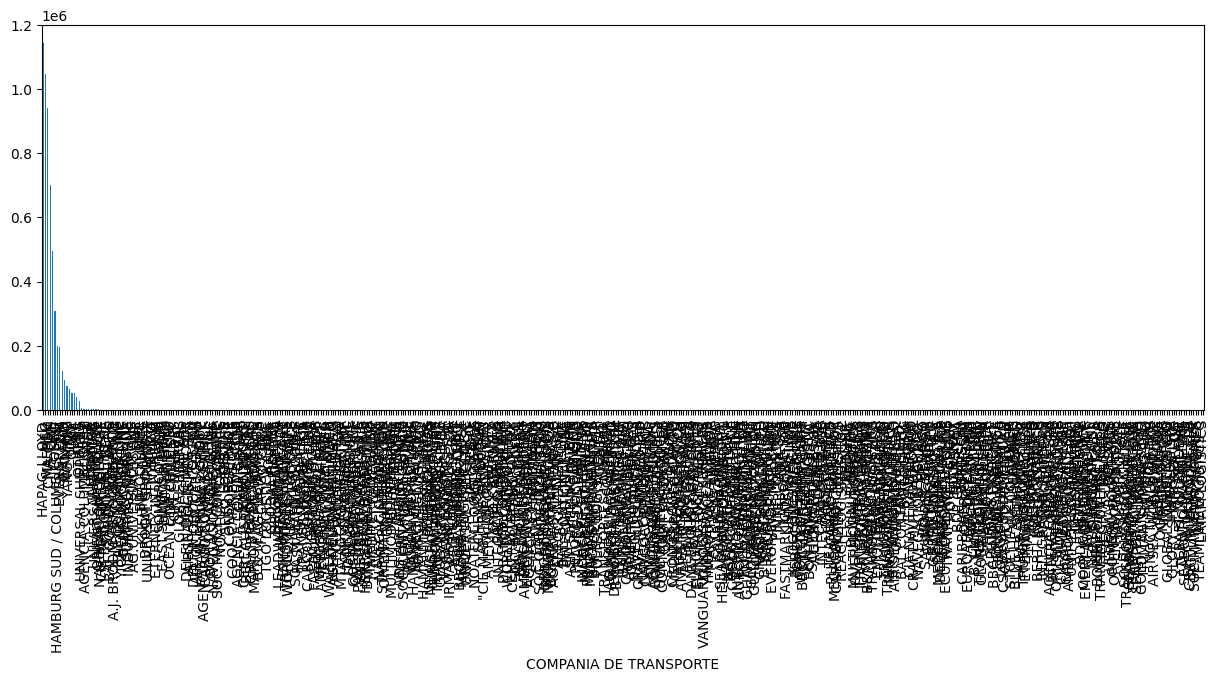

In [148]:
df["COMPANIA DE TRANSPORTE"].value_counts().plot(kind="bar", figsize=(15, 5))

<Axes: xlabel='COMPANIA DE TRANSPORTE'>

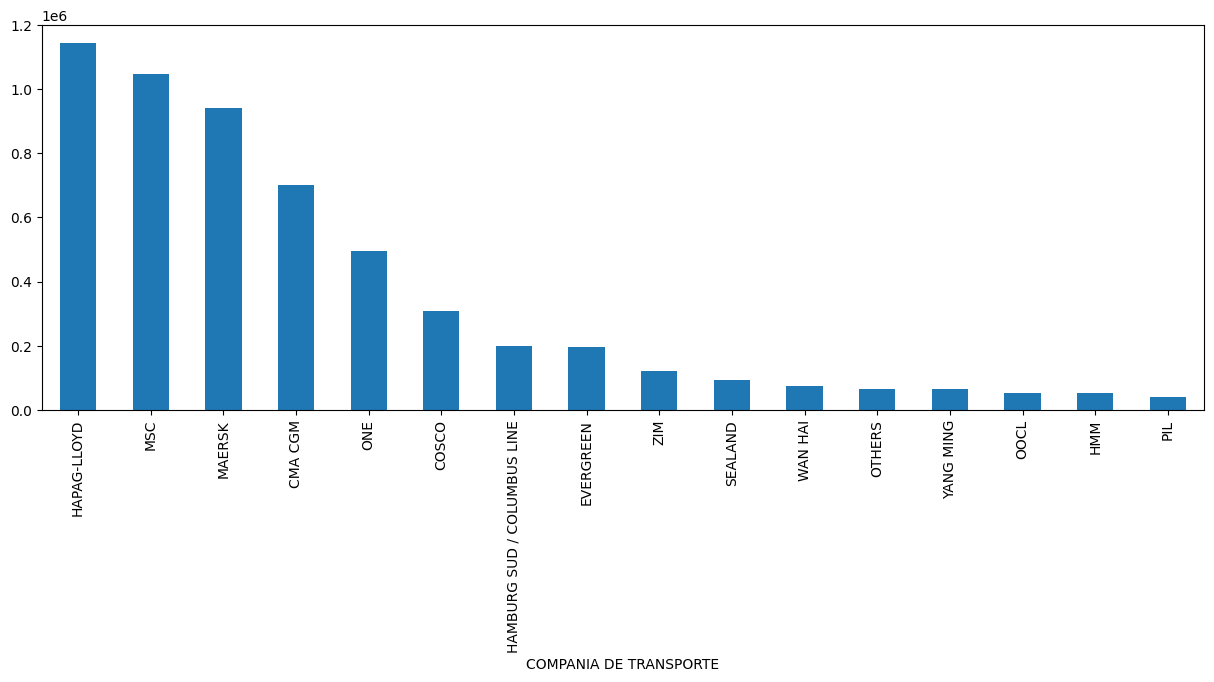

In [149]:
frecuencias = df["COMPANIA DE TRANSPORTE"].value_counts(normalize=True) * 100

# Identificar los que representan menos del 0.5%
menos_frecuentes = frecuencias[frecuencias < 0.5].index
df["COMPANIA DE TRANSPORTE"] = np.where(
    df["COMPANIA DE TRANSPORTE"].isin(menos_frecuentes),
    "OTHERS",
    df["COMPANIA DE TRANSPORTE"],
)
df["COMPANIA DE TRANSPORTE"] = np.where(
    df["COMPANIA DE TRANSPORTE"] == "NO EXISTE", "OTHERS", df["COMPANIA DE TRANSPORTE"]
)
df["COMPANIA DE TRANSPORTE"].value_counts().plot(kind="bar", figsize=(15, 5))

In [150]:
df["TIPO DE BULTO"].value_counts()
df["TIPO DE BULTO"] = df["TIPO DE BULTO"].map(
    {
        "CONTENEDOR 40": 0,
        "CONTENEDOR 20": 0,
        "CONTENEDOR NO REFRIGERADO": 0,
        "CONTENEDOR REFRIGERADO 40": 2,
        "CONTENEDOR REFRIGERADO 20": 1,
    }
)
container_type_container_count = (
    df.groupby("FECHA")["TIPO DE BULTO"].sum().reset_index()
)
container_type_container_count

,FECHA,TIPO DE BULTO
0,2022-01-01,2
1,2022-01-02,38
2,2022-01-03,743
3,2022-01-04,784
4,2022-01-05,1248
...,...,...
1089,2024-12-27,1234
1090,2024-12-28,74
1091,2024-12-29,28
1092,2024-12-30,886


In [151]:
df["PAIS DE ORIGEN"].value_counts()

PAIS DE ORIGEN
CHINA                            2640366
U.S.A                             504929
ALEMANIA                          246088
ORIGEN O DESTINO NO PRECISADO     232947
MEXICO                            187686
                                  ...   
PAPUA NUEVA GUINEA                     1
DOMINICA                               1
UGANDA                                 1
LIBERIA                                1
GUYANA                                 1
Name: count, Length: 161, dtype: int64

In [152]:
frecuencias = df["PAIS DE ORIGEN"].value_counts(normalize=True) * 100

# Identificar los que representan menos del 0.5%
menos_frecuentes = frecuencias[frecuencias < 1.5].index
df2 = df.copy()
df["PAIS DE ORIGEN"] = np.where(
    df["PAIS DE ORIGEN"].isin(menos_frecuentes), "OTHERS", df["PAIS DE ORIGEN"]
)
print(df["PAIS DE ORIGEN"].nunique())
df["PAIS DE ORIGEN"].value_counts()

13


PAIS DE ORIGEN
CHINA                            2640366
OTHERS                            911033
U.S.A                             504929
ALEMANIA                          246088
ORIGEN O DESTINO NO PRECISADO     232947
MEXICO                            187686
ESPANA                            181664
FRANCIA                           160452
ITALIA                            148285
COLOMBIA                          103469
VIETNAM                           101239
INDIA                              92709
PERU                               84285
Name: count, dtype: int64

In [153]:
clausula_container_count = (
    df.groupby(["FECHA", "CLAUSULA"])["CANTIDAD DE BULTO"].sum().reset_index()
)
pivot_clausula_count = (
    clausula_container_count.pivot(
        index="FECHA", columns="CLAUSULA", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
company_container_count = (
    df.groupby(["FECHA", "COMPANIA DE TRANSPORTE"])["CANTIDAD DE BULTO"]
    .sum()
    .reset_index()
)
pivot_company_count = (
    company_container_count.pivot(
        index="FECHA", columns="COMPANIA DE TRANSPORTE", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
container_country_count = (
    df.groupby(["FECHA", "PAIS DE ORIGEN"])["CANTIDAD DE BULTO"].sum().reset_index()
)
pivot_country_count = (
    container_country_count.pivot(
        index="FECHA", columns="PAIS DE ORIGEN", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
pivot_country_count

PAIS DE ORIGEN,FECHA,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS,PERU,U.S.A,VIETNAM
0,2022-01-01,12.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0
1,2022-01-02,72.0,24.0,0.0,0.0,0.0,12.0,0.0,2.0,11.0,182.0,2.0,12.0,0.0
2,2022-01-03,499.0,4666.0,208.0,239.0,631.0,314.0,145.0,192.0,276.0,2067.0,77.0,1163.0,34.0
3,2022-01-04,1357.0,6503.0,741.0,691.0,1053.0,304.0,307.0,648.0,742.0,2084.0,128.0,976.0,113.0
4,2022-01-05,537.0,7036.0,196.0,608.0,50.0,354.0,186.0,159.0,383.0,1905.0,185.0,959.0,253.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,2024-12-27,487.0,10052.0,337.0,633.0,666.0,213.0,222.0,915.0,332.0,2858.0,345.0,770.0,248.0
1090,2024-12-28,86.0,963.0,0.0,84.0,0.0,54.0,0.0,18.0,18.0,58.0,2.0,30.0,19.0
1091,2024-12-29,36.0,1522.0,14.0,7.0,0.0,0.0,2.0,10.0,0.0,9.0,14.0,0.0,0.0
1092,2024-12-30,660.0,11340.0,235.0,444.0,464.0,154.0,363.0,218.0,527.0,4418.0,239.0,1885.0,79.0


In [154]:
daily_df = pd.DataFrame({"FECHA": df["FECHA"].dropna().sort_values().unique()})
daily_df.FECHA = pd.to_datetime(daily_df.FECHA)
daily_df.head()

,FECHA
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05


In [155]:
quantity_daily = df.groupby("FECHA")["CANTIDAD DE BULTO"].sum().reset_index()
rut_diario = df.groupby("FECHA")["RUT PROBABLE IMPORTADOR"].nunique().reset_index()
rut_diario.rename(
    columns={"RUT PROBABLE IMPORTADOR": "RUTS_UNICOS_DIARIOS"}, inplace=True
)
daily_df = pd.merge(daily_df, rut_diario, how="outer", on="FECHA")
daily_df = pd.merge(daily_df, pivot_clausula_count, how="outer", on="FECHA")
daily_df = pd.merge(daily_df, pivot_company_count, how="outer", on="FECHA")
daily_df = pd.merge(daily_df, quantity_daily, how="outer", on="FECHA")
daily_df = pd.merge(daily_df, container_type_container_count, how="outer", on="FECHA")
daily_df = pd.merge(daily_df, pivot_country_count, how="outer", on="FECHA")

cols = [
    "DIFF_DAYS",
    "FOB_POR_BULTO",
    "SEGURO_POR_BULTO",
    "FLETE_POR_BULTO",
    "PESO BRUTO POR CONTENEDOR",
    "ITEMS POR CONTENEDOR",
]
agg_funcs = ["mean", "max", "std"]

for col in cols:
    agg_df = df.groupby("FECHA")[col].agg(agg_funcs).reset_index()
    agg_df.columns = ["FECHA"] + [f"{func.upper()}_{col}" for func in agg_funcs]
    daily_df = pd.merge(daily_df, agg_df, how="outer", on="FECHA")
daily_df

,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS_x,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS_y,PERU,U.S.A,VIETNAM,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR
0,2022-01-01,8,43.0,12.0,64.0,0.0,2.0,0.0,8.0,0.0,12.0,0.0,0.0,97.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,119,2,12.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0,37.229508,78.0,9.522593,54086.059672,218872.22,58345.740657,131.151885,658.475,183.369689,4391.022377,84634.97,10940.155571,16331.003361,364680.00,46831.596085,9.704918,15.0,5.655659
1,2022-01-02,20,190.0,2.0,125.0,0.0,136.0,70.0,0.0,26.0,6.0,2.0,18.0,48.0,7.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,317,38,72.0,24.0,0.0,0.0,0.0,12.0,0.0,2.0,11.0,182.0,2.0,12.0,0.0,69.384106,325.0,94.932738,75147.798707,369137.97,79922.499736,70.834684,724.050,90.360458,3436.720718,17100.00,3234.139906,7312.921121,90978.30,9960.775861,16.933908,34.0,14.474512
2,2022-01-03,621,3025.0,1221.0,5658.0,607.0,739.0,686.0,228.0,1221.0,2730.0,368.0,345.0,2220.0,1469.0,291.0,30.0,19.0,26.0,117.0,22.0,0.0,10511,743,499.0,4666.0,208.0,239.0,631.0,314.0,145.0,192.0,276.0,2067.0,77.0,1163.0,34.0,63.319355,358.0,73.151841,46961.185834,490566.47,52840.379248,191.316192,8435.750,412.726432,6101.167023,101152.88,8073.935576,10981.448108,441010.00,21659.664945,12.187080,135.0,22.767872
3,2022-01-04,731,4157.0,2260.0,8042.0,1188.0,1200.0,358.0,304.0,1689.0,4732.0,173.0,863.0,3792.0,2070.0,39.0,133.0,52.0,45.0,149.0,48.0,0.0,15647,784,1357.0,6503.0,741.0,691.0,1053.0,304.0,307.0,648.0,742.0,2084.0,128.0,976.0,113.0,71.970984,7632.0,270.904010,66606.724245,778665.44,67514.193933,149.352462,7181.410,280.032023,5857.868454,143400.00,9641.245609,11250.545017,730132.40,27560.923462,25.646908,140.5,37.359844
4,2022-01-05,733,2436.0,1552.0,7799.0,1024.0,853.0,470.0,354.0,1076.0,3224.0,383.0,1169.0,2786.0,1785.0,163.0,142.0,84.0,67.0,135.0,120.0,0.0,12811,1248,537.0,7036.0,196.0,608.0,50.0,354.0,186.0,159.0,383.0,1905.0,185.0,959.0,253.0,80.602031,359.0,96.669536,58045.942307,2471211.25,73171.871705,246.934353,7984.440,614.498340,7725.705485,205562.22,12037.981640,13391.804848,495985.77,30015.627216,13.954526,130.0,22.200506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,2024-12-27,1003,4766.0,1547.0,10434.0,1331.0,2221.0,1596.0,1404.0,0.0,3483.0,142.0,3430.0,2439.0,2177.0,199.0,64.0,148.0,0.0,348.0,11.0,416.0,18078,1234,487.0,10052.0,337.0,633.0,666.0,213.0,222.0,915.0,332.0,2858.0,345.0,770.0,248.0,68.241889,1529.0,87.502579,71992.930499,3744929.50,197228.971212,227.647998,67130.000,1125.300377,2557.866168,79800.00,4120.044650,14601.751861,1604315.00,36860.989252,14.593781,107.5,22.843803
1090,2024-12-28,80,300.0,54.0,784.0,194.0,127.0,124.0,124.0,0.0,160.0,28.0,367.0,84.0,214.0,6.0,68.0,0.0,0.0,2.0,0.0,28.0,1332,74,86.0,963.0,0.0,84.0,0.0,54.0,0.0,18.0,18.0,58.0,2.0,30.0,19.0,59.926657,352.0,64.265650,41737.442791,527890.81,57653.204853,139.789846,1528.995,258.539614,2958.673170,90000.00,7893.286167,10021.276725,333000.00,17033.883122,9.257363,35.0,9.968421
1091,2024-12-29,147,118.0,49.0,1437.0,10.0,76.0,401.0,380.0,0.0,316.0,0.0,276.0,37.0,10.0,10.0,0.0,0.0,0.0,20.0,0.0,88.0,1614,28,36.0,1522.0,14.0,7.0,0.0,0.0,2.0,10.0,0.0,9.0,14.0,0.0,0.0,46.891720,322.0,37.997988,27858.491316,629250.44,55894.683870,378.853571,1547.120,361.956836,2703.748643,900

In [156]:
original_columns = set(daily_df.columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5595152 entries, 0 to 5595151
Data columns (total 19 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   NUMERO DE ACEPTACION       int64         
 1   RUT PROBABLE IMPORTADOR    object        
 2   PAIS DE ORIGEN             object        
 3   PUERTO DE EMBARQUE         object        
 4   PUERTO DE DESEMBARQUE      object        
 5   COMPANIA DE TRANSPORTE     object        
 6   TIPO DE BULTO              int64         
 7   CLAUSULA                   object        
 8   CANTIDAD DE BULTO          int64         
 9   CANTIDAD UNIDADES FISICAS  float64       
 10  UNIDAD DE MEDIDA FISICA    object        
 11  FECHA                      datetime64[ns]
 12  FECHA_TRANS                object        
 13  DIFF_DAYS                  float64       
 14  FOB_POR_BULTO              float64       
 15  FLETE_POR_BULTO            float64       
 16  SEGURO_POR_BULTO           float64  

In [157]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   FECHA                           1094 non-null   datetime64[ns]
 1   RUTS_UNICOS_DIARIOS             1094 non-null   int64         
 2   CD                              1094 non-null   float64       
 3   CFR                             1094 non-null   float64       
 4   F                               1094 non-null   float64       
 5   OTRO                            1094 non-null   float64       
 6   CMA CGM                         1094 non-null   float64       
 7   COSCO                           1094 non-null   float64       
 8   EVERGREEN                       1094 non-null   float64       
 9   HAMBURG SUD / COLUMBUS LINE     1094 non-null   float64       
 10  HAPAG-LLOYD                     1094 non-null   float64       
 11  HMM 

In [158]:
folder = "../data/macro"
for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df_macro = pd.read_csv(file_path)

        if "Date" in df_macro.columns:
            df_macro["FECHA"] = pd.to_datetime(df_macro["Date"], errors="coerce")
            df_macro = df_macro.sort_values("FECHA").drop(columns=["Date"])
            df_macro[["Close", "Volume"]] = (
                df_macro[["Close", "Volume"]]
                .fillna(method="ffill")
                .fillna(method="bfill")
            )
            df_macro["Close_pct_change"] = df_macro["Close"].pct_change().fillna(0)

            # df_macro.to_csv("test_macro.csv", index=False)

            if "Close" in df_macro.columns and "Volume" in df_macro.columns:
                df_macro[["Close", "Volume"]] = df_macro[["Close", "Volume"]].fillna(
                    method="ffill"
                )

                name = filename.replace(".csv", "").lower()  # e.g. 'data_gold'
                macro_filtered = df_macro[
                    ["FECHA", "Close", "Volume", "Close_pct_change"]
                ].rename(
                    columns={
                        "Close": f"{name}_price",
                        "Volume": f"{name}_volume",
                        "Close_pct_change": f"{name}_pct_change",
                    }
                )

                daily_df = pd.merge(daily_df, macro_filtered, how="left", on="FECHA")

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_40472/923904432.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[['Close', 'Volume']] = df_macro[['Close', 'Volume']].fillna(method='ffill').fillna(method='bfill')
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_40472/923904432.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[['Close', 'Volume']] = df_macro[['Close', 'Volume']].fillna(method='ffill')
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_40472/923904432.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[['Close', 'Volume']] = df_macro[['Close', 'Volume']].fillna(method='ffill').fillna(method='bfill')
/var/folders/dy/8nkgqf653sggg31kzy33mjd

In [159]:
new_columns = [col for col in daily_df.columns if col not in original_columns]
daily_df[new_columns] = (
    daily_df[new_columns].fillna(method="ffill").fillna(method="bfill")
)
daily_df

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_40472/707595914.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df[new_columns] = daily_df[new_columns].fillna(method='ffill').fillna(method='bfill')


,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS_x,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHERS_y,PERU,U.S.A,VIETNAM,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR,wan_hai_price,wan_hai_volume,wan_hai_pct_change,data_gold_price,data_gold_volume,data_gold_pct_change,zim_price,zim_volume,zim_pct_change,sea_price,sea_volume,sea_pct_change,ipsa_price,ipsa_volume,ipsa_pct_change,cny_price,cny_volume,cny_pct_change,clp_price,clp_volume,clp_pct_change,wti_oil_price,wti_oil_volume,wti_oil_pct_change,csi300_price,csi300_volume,csi300_pct_change,brent_oil_price,brent_oil_volume,brent_oil_pct_change,maersk_price,maersk_volume,maersk_pct_change,hapag_price,hapag_volume,hapag_pct_change,yang_ming_price,yang_ming_volume,yang_ming_pct_change,cosco_shipping_price,cosco_shipping_volume,cosco_shipping_pct_change,boat_price,boat_volume,boat_pct_change,sp500_price,sp500_volume,sp500_pct_change
0,2022-01-01,8,43.0,12.0,64.0,0.0,2.0,0.0,8.0,0.0,12.0,0.0,0.0,97.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,119,2,12.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0,37.229508,78.0,9.522593,54086.059672,218872.22,58345.740657,131.151885,658.475,183.369689,4391.022377,84634.97,10940.155571,16331.003361,364680.00,46831.596085,9.704918,15.0,5.655659,163.043472,57287017.0,-0.055416,1799.400024,116.0,-0.015376,56.759998,3252400.0,-0.035678,20.105,7500.0,0.000000,5058.879883,0.0,0.0,6.3549,0.0,-0.002699,851.500000,0.0,0.000000,76.080002,317628.0,0.011568,4917.770020,151500.0,-0.004575,78.980003,27224.0,0.015428,24100.0,23192.0,0.027719,287.399994,27227.0,0.037545,114.500000,106421791.0,-0.053719,16.08,54332784.0,0.063492,30.540001,19100.0,0.026417,4796.560059,3.831020e+09,0.006374
1,2022-01-02,20,190.0,2.0,125.0,0.0,136.0,70.0,0.0,26.0,6.0,2.0,18.0,48.0,7.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,317,38,72.0,24.0,0.0,0.0,0.0,12.0,0.0,2.0,11.0,182.0,2.0,12.0,0.0,69.384106,325.0,94.932738,75147.798707,369137.97,79922.499736,70.834684,724.050,90.360458,3436.720718,17100.00,3234.139906,7312.921121,90978.30,9960.775861,16.933908,34.0,14.474512,163.043472,57287017.0,-0.055416,1799.400024,116.0,-0.015376,56.759998,3252400.0,-0.035678,20.105,7500.0,0.000000,5058.879883,0.0,0.0,6.3549,0.0,-0.002699,851.500000,0.0,0.000000,76.080002,317628.0,0.011568,4917.770020,151500.0,-0.004575,78.980003,27224.0,0.015428,24100.0,23192.0,0.027719,287.399994,27227.0,0.037545,114.500000,106421791.0,-0.053719,16.08,54332784.0,0.063492,30.540001,19100.0,0.026417,4796.560059,3.831020e+09,0.006374
2,2022-01-03,621,3025.0,1221.0,5658.0,607.0,739.0,686.0,228.0,1221.0,2730.0,368.0,345.0,2220.0,1469.0,291.0,30.0,19.0,26.0,117.0,22.0,0.0,10511,743,499.0,4666.0,208.0,239.0,631.0,314.0,145.0,192.0,276.0,2067.0,77.0,1163.0,34.0,63.319355,358.0,73.151841,46961.185834,490566.47,52840.379248,191.316192,8435.750,412.726432,6101.167023,101152.88,8073.935576,10981.448108,441010.00,21659.664945,12.187080,135.0,22.767872,163.043472,57287017.0,-0.055416,1799.400024,116.0,-0.015376,56.759998,3252400.0,-0.035678,20.105,7500.0,0.000000,5058.879883,0.0,0.0,6.3549,0.0,-0.002699,851.500000,0.0,0.000000,76.080002,317628.0,0.011568,4917.770020,151500.0,-0.004575,78.980003,27224.0,0.015428,24100.0,23192.0,0.027719,287.399994,27227.0,0.037545,114.500000,106421791.0,-0.053719,16.08,54332784.0,0.063492,30.540001,19100.0,0.026417,4796.560059,3.831020e+09,0.006374
3,2022-01-04,731,4157.0,2260.0,8042.0,1188.0,1200.0,358.0,304.0,1689.0,4732.0,173.0,863.0,3792.0,2070.0,39.0,133.0,52.0,45.0,149.0,48.0,0.0,15

In [161]:
daily_df.to_csv("../data/proc/test_daily_kz.csv", index=False)